In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("credit_risk_dataset_clean.csv")

df.head(10)

,age,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,debit_card_spending,mobile_banking_logins,online_transfer_frequency,...,gender_female,gender_male,gender_other,employment_status_Employed,employment_status_Self-Employed,employment_status_Unemployed,debt_to_income_ratio,loan_to_income_ratio,spending_ratio,balance_to_debt_ratio
0,58,58137.751192,115,524.679407,1,171.342369,49,768.877511,9,16,...,0,1,0,0,0,1,0.248297,0.266790,0.013225,0.036344
1,48,26174.922827,32,2635.203357,1,985.607164,1,580.287785,9,1,...,0,1,0,0,1,0,0.430301,0.566169,0.022170,0.233947
2,34,75566.837265,14,2334.341061,9,994.310119,42,564.013508,36,5,...,0,0,1,0,0,1,0.198727,0.144373,0.007464,0.155435
3,62,35197.961516,179,2425.384332,10,366.115346,4,838.489200,31,7,...,0,1,0,0,1,0,0.358718,0.014205,0.023822,0.192077
4,27,12136.998349,225,10.000000,8,786.752258,16,462.495522,35,16,...,1,0,0,0,1,0,1.118621,0.783933,0.038106,0.000737
5,40,76906.812198,84,1260.654535,2,227.110255,36,0.000000,63,5,...,0,1,0,1,0,0,0.016479,0.070527,0.000000,0.993950
6,58,14485.730000,48,1437.594031,3,20.000000,34,633.589112,14,11,...,1,0,0,1,0,0,0.922038,0.621617,0.043739,0.107625
7,38,67355.217921,173,1959.997183,0,426.243321,7,788.186496,72,15,...,1,0,0,1,0,0,0.271024,0.187555,0.011702,0.107363
8,42,62980.151376,132,2220.699649,0,584.181270,42,618.813748,15,5,...,1,0,0,1,0,0,0.133005,0.151457,0.009826,0.265073
9,30,55751.973822,99,2527.700512,3,1025.489663,2,180.263305,45,1,...,1,0,0,0,1,0,0.322439,0.051956,0.003233,0.140603


il faut spécifier les variables indépendants (feature) et le varible cible (target): 

1.séparation des données
====================================

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split



# Variable cible
y = df["credit_risk"]

# Variables explicatives
X = df.drop(
    ["credit_risk", "credit_score"],
    axis=1
)
# Séparation entraînement / test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Taille de l'ensemble d'entraînement :", X_train.shape)
print("Taille de l'ensemble de test :", X_test.shape)

Taille de l'ensemble d'entraînement : (3500, 27)
Taille de l'ensemble de test : (1500, 27)


2.Normalisation
==============================

In [3]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(3500, 27)
(1500, 27)


3.Régression logistique
================================

In [4]:
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Data augmentation avec SMOTE
smote = SMOTE(random_state=42)

X_train_aug, y_train_aug = smote.fit_resample(X_train_scaled, y_train)

print("Avant SMOTE :")
print(y_train.value_counts())

print("\nAprès SMOTE :")
print(y_train_aug.value_counts())

# Hyperparamètres
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Entraînement sur les données augmentées
grid.fit(X_train_aug, y_train_aug)

print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur score CV :", grid.best_score_)

# Meilleur modèle
best_lr = grid.best_estimator_

# Prédictions sur test normal
y_pred = best_lr.predict(X_test_scaled)

# Probabilités
y_proba = best_lr.predict_proba(X_test_scaled)[:, 1]

# Métriques
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Avant SMOTE :
credit_risk
1    2680
0     820
Name: count, dtype: int64

Après SMOTE :
credit_risk
1    2680
0    2680
Name: count, dtype: int64
Meilleurs paramètres : {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Meilleur score CV : 0.8451464576540089
Accuracy  : 0.7860
Precision : 0.9414
Recall    : 0.7685
F1-Score  : 0.8462
ROC-AUC   : 0.8565

Classification Report
              precision    recall  f1-score   support

           0       0.53      0.84      0.65       351
           1       0.94      0.77      0.85      1149

    accuracy                           0.79      1500
   macro avg       0.73      0.81      0.75      1500
weighted avg       0.84      0.79      0.80      1500


Confusion Matrix
[[296  55]
 [266 883]]


4.Random Forest
===================

In [5]:
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix
)

# Data augmentation avec SMOTE
smote = SMOTE(random_state=42)

X_train_aug, y_train_aug = smote.fit_resample(X_train, y_train)

print("Avant SMOTE :")
print(y_train.value_counts())

print("\nAprès SMOTE :")
print(y_train_aug.value_counts())

# Création du modèle Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

# Entraînement sur les données augmentées
rf.fit(X_train_aug, y_train_aug)

# Prédictions sur les données de test normales
y_pred_rf = rf.predict(X_test)

# Probabilités pour le pourcentage de risque
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Évaluation
print("Accuracy  :", accuracy_score(y_test, y_pred_rf))
print("Precision :", precision_score(y_test, y_pred_rf))
print("Recall    :", recall_score(y_test, y_pred_rf))
print("F1-score  :", f1_score(y_test, y_pred_rf))
print("ROC-AUC   :", roc_auc_score(y_test, y_proba_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

Avant SMOTE :
credit_risk
1    2680
0     820
Name: count, dtype: int64

Après SMOTE :
credit_risk
1    2680
0    2680
Name: count, dtype: int64
Accuracy  : 0.7886666666666666
Precision : 0.8802559414990859
Recall    : 0.8381201044386423
F1-score  : 0.8586714222024074
ROC-AUC   : 0.8623527457295952

Classification Report
              precision    recall  f1-score   support

           0       0.54      0.63      0.58       351
           1       0.88      0.84      0.86      1149

    accuracy                           0.79      1500
   macro avg       0.71      0.73      0.72      1500
weighted avg       0.80      0.79      0.79      1500


Confusion Matrix
[[220 131]
 [186 963]]


5.XGBoost
=============================

In [6]:
# Si nécessaire :
# pip install xgboost

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix
)

# Data augmentation avec SMOTE
smote = SMOTE(random_state=42)
X_train_aug, y_train_aug = smote.fit_resample(X_train, y_train)

print("Avant SMOTE :")
print(y_train.value_counts())

print("\nAprès SMOTE :")
print(y_train_aug.value_counts())

# Création du modèle XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# Entraînement
xgb.fit(X_train_aug, y_train_aug)

# Prédictions
y_pred_xgb = xgb.predict(X_test)

# Probabilités
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

# Évaluation
print("Accuracy  :", accuracy_score(y_test, y_pred_xgb))
print("Precision :", precision_score(y_test, y_pred_xgb))
print("Recall    :", recall_score(y_test, y_pred_xgb))
print("F1-score  :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC   :", roc_auc_score(y_test, y_proba_xgb))

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))

Avant SMOTE :
credit_risk
1    2680
0     820
Name: count, dtype: int64

Après SMOTE :
credit_risk
1    2680
0    2680
Name: count, dtype: int64
Accuracy  : 0.782
Precision : 0.9101796407185628
Recall    : 0.793733681462141
F1-score  : 0.8479776847977685
ROC-AUC   : 0.8697938750158072

Classification Report
              precision    recall  f1-score   support

           0       0.52      0.74      0.61       351
           1       0.91      0.79      0.85      1149

    accuracy                           0.78      1500
   macro avg       0.72      0.77      0.73      1500
weighted avg       0.82      0.78      0.79      1500


Confusion Matrix
[[261  90]
 [237 912]]


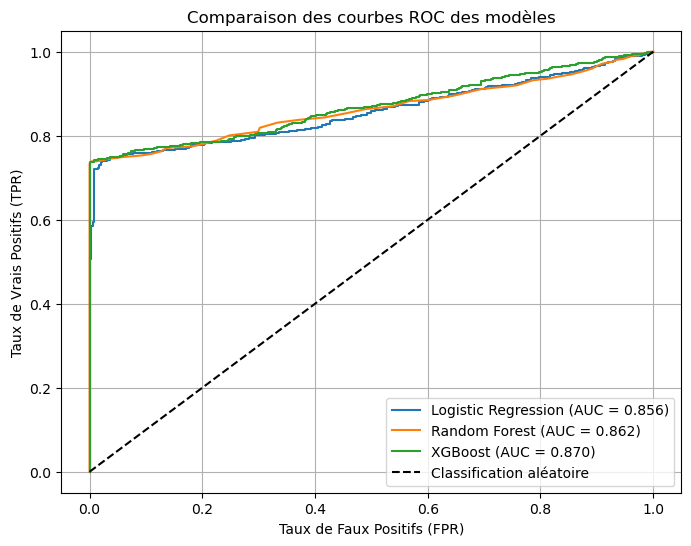

In [7]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Logistic Regression
y_proba_lr = best_lr.predict_proba(X_test_scaled)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

# Random Forest
y_proba_rf = rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

# XGBoost
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

# Tracé
plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression (AUC = {auc_lr:.3f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {auc_rf:.3f})'
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f'XGBoost (AUC = {auc_xgb:.3f})'
)

# Classification aléatoire
plt.plot([0, 1], [0, 1], 'k--', label='Classification aléatoire')

plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Comparaison des courbes ROC des modèles')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

w eli bch ne5tarouh bch na3mlou enregistrement avec joblib


In [10]:
import joblib
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(xgb, 'xgboost_credit_risk_model.pkl')

['xgboost_credit_risk_model.pkl']